In [21]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
# Style global 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# Import Data 

In [2]:

df_raw = pd.read_csv("hf://datasets/mindweave/web-server-logs/data/access_logs.csv")
print(f"Dataset chargé : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes")

Dataset chargé : 5000 lignes, 10 colonnes


In [3]:
print("*"*50)
print ("Data Exploration:")
print("*"*50)
print("1. Data Header:")
print(df_raw.head())
print("2. Data Info:")
df_raw.info()
print("3. Missing Values:")
print(df_raw.isnull().sum())
print("4. Statistical Description:")
print(df_raw.describe())
print("5. Duplicate Rows:")
print(df_raw.duplicated().sum())
print("6. Unique Values per Column:")
for col in df_raw.columns:
    print(f"{col}: {df_raw[col].nunique()} unique values")


**************************************************
Data Exploration:
**************************************************
1. Data Header:
             timestamp  server_id method                      path  \
0  2024-01-01 00:15:12          1    GET  /api/v2/payments/process   
1  2024-01-01 00:27:54          2    GET                     /docs   
2  2024-01-01 00:31:42          1   POST              /api/v2/cart   
3  2024-01-01 00:54:33          2   POST         /static/js/app.js   
4  2024-01-01 01:36:08          2    GET                  /contact   

   status_code  response_time_ms  bytes_sent  \
0          201               153        2256   
1          304               290       10395   
2          200               201        2452   
3          201                31        2324   
4          200                64         449   

                                          user_agent      ip_address  \
0                                 Go-http-client/2.0    107.8.181.20   
1     Bing

In [4]:
print("DISTRIBUTION STATUS CODES")
print(df_raw["status_code"].value_counts().sort_index())

print(" DISTRIBUTION SERVER ID ")
print(df_raw["server_id"].value_counts().sort_index())

print("DISTRIBUTION MÉTHODES HTTP")
print(df_raw["method"].value_counts())

DISTRIBUTION STATUS CODES
status_code
200    3638
201     245
301     118
304     292
400     192
401     156
403      52
404     197
500      85
503      25
Name: count, dtype: int64
 DISTRIBUTION SERVER ID 
server_id
1    1670
2    1642
3    1688
Name: count, dtype: int64
DISTRIBUTION MÉTHODES HTTP
method
GET       3360
POST      1013
PUT        378
DELETE     158
PATCH       91
Name: count, dtype: int64


#  Distribution des status codes 

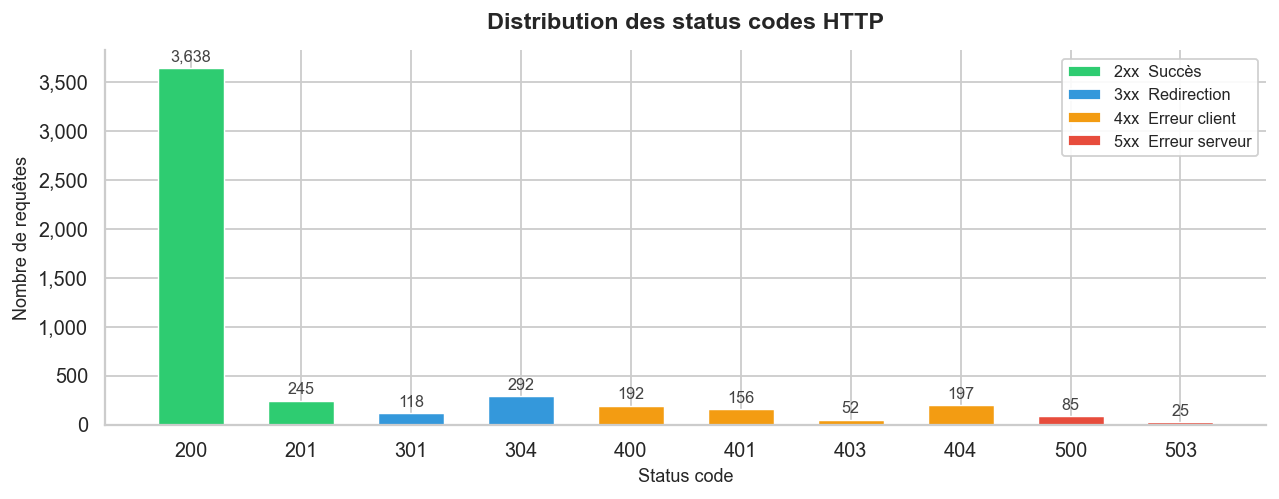

Figure sauvegardée : status_codes_distribution.png


In [5]:
df = df_raw.copy()
status_counts = df["status_code"].value_counts().sort_index()

# Palette par famille
def status_color(code):
    if 200 <= code <= 299: return "#2ecc71"   # vert
    if 300 <= code <= 399: return "#3498db"   # bleu
    if 400 <= code <= 499: return "#f39c12"   # orange
    if 500 <= code <= 599: return "#e74c3c"   # rouge
    return "#95a5a6"

colors = [status_color(c) for c in status_counts.index]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(status_counts.index.astype(str), status_counts.values,
              color=colors, width=0.6, edgecolor="white", linewidth=0.8)

# Annotations de valeur sur chaque barre
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(status_counts)*0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=9, color="#444")

ax.set_title("Distribution des status codes HTTP", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Status code", fontsize=10)
ax.set_ylabel("Nombre de requêtes", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

legend_elements = [
    Patch(facecolor="#2ecc71", label="2xx  Succès"),
    Patch(facecolor="#3498db", label="3xx  Redirection"),
    Patch(facecolor="#f39c12", label="4xx  Erreur client"),
    Patch(facecolor="#e74c3c", label="5xx  Erreur serveur"),
]
ax.legend(handles=legend_elements, loc="upper right", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("status_codes_distribution.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : status_codes_distribution.png")

# **2. NETTOYAGE**

In [6]:
df = df_raw.copy()

# Convertir timestamp en datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"Timestamp converti : {df['timestamp'].dtype}")

# Remplacer les referrer "-" par NaN
df["referrer"] = df["referrer"].replace("-", np.nan)
print(f"Referrer nettoyé : {df['referrer'].isnull().sum()} valeurs manquantes")
# S'assurer que les colonnes numériques sont bien typées
df["response_time_ms"] = pd.to_numeric(df["response_time_ms"], errors="coerce")
df["bytes_sent"]       = pd.to_numeric(df["bytes_sent"], errors="coerce")
df["status_code"]      = pd.to_numeric(df["status_code"], errors="coerce")
print(f"Types corrigés")
print(df.dtypes)

Timestamp converti : datetime64[ns]
Referrer nettoyé : 997 valeurs manquantes
Types corrigés
timestamp           datetime64[ns]
server_id                    int64
method                      object
path                        object
status_code                  int64
response_time_ms             int64
bytes_sent                   int64
user_agent                  object
ip_address                  object
referrer                    object
dtype: object


In [7]:
avant = len(df)
df = df.drop_duplicates()
apres = len(df)
print(f"Doublons supprimés : {avant - apres}")
print(f"Lignes restantes   : {apres}")

Doublons supprimés : 0
Lignes restantes   : 5000


In [8]:
df["referrer"] = df["referrer"].fillna("direct")
print("Valeurs manquantes traitées")
print(df.isnull().sum())

Valeurs manquantes traitées
timestamp           0
server_id           0
method              0
path                0
status_code         0
response_time_ms    0
bytes_sent          0
user_agent          0
ip_address          0
referrer            0
dtype: int64


### 2.2 Suppression des lignes corrompues

In [9]:
# Supprimer les lignes avec response_time négatif ou nul
df = df[df["response_time_ms"] > 0]

# Supprimer les lignes avec bytes_sent négatif
df = df[df["bytes_sent"] >= 0]

# Supprimer les status codes invalides
df = df[df["status_code"].between(100, 599)]

print(f"Lignes corrompues supprimées")
print(f"Lignes finales : {len(df)}")

Lignes corrompues supprimées
Lignes finales : 5000


# **3. PARSING & ENRICHISSEMENT**

### 3.1 Parsing du status code

In [10]:
# Catégorisation des status codes
df["is_success"]   = df["status_code"].between(200, 299).astype(int)
df["is_redirect"]  = df["status_code"].between(300, 399).astype(int)
df["is_error_4xx"] = df["status_code"].between(400, 499).astype(int)
df["is_error_5xx"] = df["status_code"].between(500, 599).astype(int)

# Colonne catégorielle lisible
def categorize_status(code):
    if 200 <= code <= 299: return "success"
    if 300 <= code <= 399: return "redirect"
    if 400 <= code <= 499: return "client_error"
    if 500 <= code <= 599: return "server_error"
    return "unknown"

df["status_category"] = df["status_code"].apply(categorize_status)

print("Status codes parsés")
print(df["status_category"].value_counts())

Status codes parsés
status_category
success         3883
client_error     597
redirect         410
server_error     110
Name: count, dtype: int64


### 3.2 Parsing du user_agent

In [11]:
def classify_agent(ua):
    if pd.isna(ua):
        return "unknown"
    ua = ua.lower()
    bots = ["bot", "crawler", "spider", "curl", "python", "postman", "go-http"]
    if any(b in ua for b in bots):
        return "bot"
    if any(m in ua for m in ["android", "iphone", "mobile", "pixel"]):
        return "mobile"
    if "macintosh" in ua or "windows" in ua:
        return "desktop"
    return "other"

df["client_type"] = df["user_agent"].apply(classify_agent)

print("User agents classifiés")
print(df["client_type"].value_counts())

User agents classifiés
client_type
bot        2975
mobile     1027
desktop     998
Name: count, dtype: int64


### 3.3 Parsing du path (endpoint)

In [12]:
def classify_path(path):
    if pd.isna(path):
        return "unknown"
    if "/api/" in path:
        return "api"
    if "/static/" in path:
        return "static"
    if any(x in path for x in ["/login", "/register", "/auth"]):
        return "auth"
    if "/admin" in path:
        return "admin"
    return "page"

df["endpoint_type"] = df["path"].apply(classify_path)

# Extraire le nom de l'endpoint API principal
def extract_api_name(path):
    parts = path.strip("/").split("/")
    # /api/v2/payments/process → "payments"
    if len(parts) >= 3 and parts[0] == "api":
        return parts[2] if len(parts) > 2 else parts[-1]
    return "non-api"

df["api_name"] = df["path"].apply(extract_api_name)

print("Endpoints parsés")


Endpoints parsés


### 3.4 Extraction des features temporelles

In [13]:
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["dayofweek"]= df["timestamp"].dt.dayofweek      # 0=lundi, 6=dimanche
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["is_business_hours"] = df["hour"].between(8, 18).astype(int)

print("Features temporelles extraites")
df[["timestamp", "hour", "dayofweek", "is_weekend", "is_business_hours"]].head(5)

Features temporelles extraites


,timestamp,hour,dayofweek,is_weekend,is_business_hours
0,2024-01-01 00:15:12,0,0,0,0
1,2024-01-01 00:27:54,0,0,0,0
2,2024-01-01 00:31:42,0,0,0,0
3,2024-01-01 00:54:33,0,0,0,0
4,2024-01-01 01:36:08,1,0,0,0


#  Heatmap requêtes par heure × jour de semaine

In [14]:
print(df.columns.tolist())
print(df.shape)

['timestamp', 'server_id', 'method', 'path', 'status_code', 'response_time_ms', 'bytes_sent', 'user_agent', 'ip_address', 'referrer', 'is_success', 'is_redirect', 'is_error_4xx', 'is_error_5xx', 'status_category', 'client_type', 'endpoint_type', 'api_name', 'hour', 'minute', 'dayofweek', 'day', 'month', 'is_weekend', 'is_business_hours']
(5000, 25)


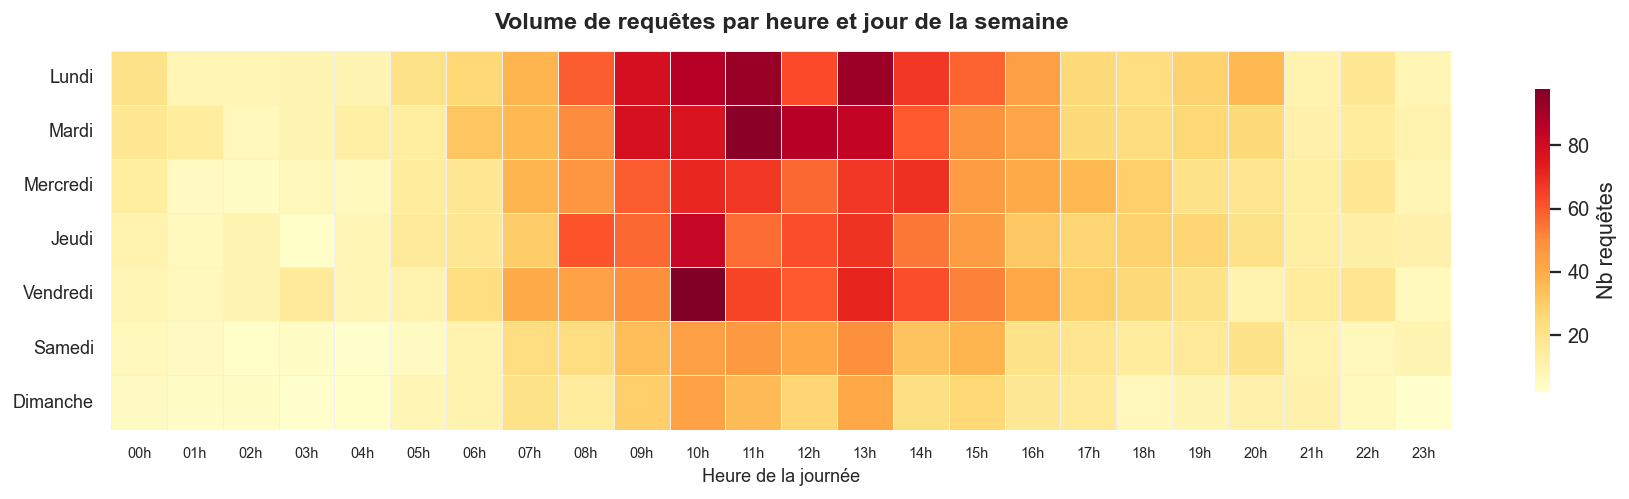

Figure sauvegardée : heatmap_trafic.png


In [15]:
pivot = (
    df.groupby(["dayofweek", "hour"])
      .size()
      .reset_index(name="count")
      .pivot(index="dayofweek", columns="hour", values="count")
      .fillna(0)
)
# Labels lisibles
day_labels  = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
hour_labels = [f"{h:02d}h" for h in range(24)]

# Ne garder que les jours présents dans les données
present_days = [day_labels[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="#f0f0f0",
    annot=False,
    fmt=".0f",
    cbar_kws={"label": "Nb requêtes", "shrink": 0.8},
    xticklabels=hour_labels,
    yticklabels=present_days,
)

ax.set_title("Volume de requêtes par heure et jour de la semaine",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Heure de la journée", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=8, rotation=0)
ax.tick_params(axis="y", labelsize=10, rotation=0)

plt.tight_layout()
plt.savefig("heatmap_trafic.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : heatmap_trafic.png")

# Montre la fréquence des temps de réponse

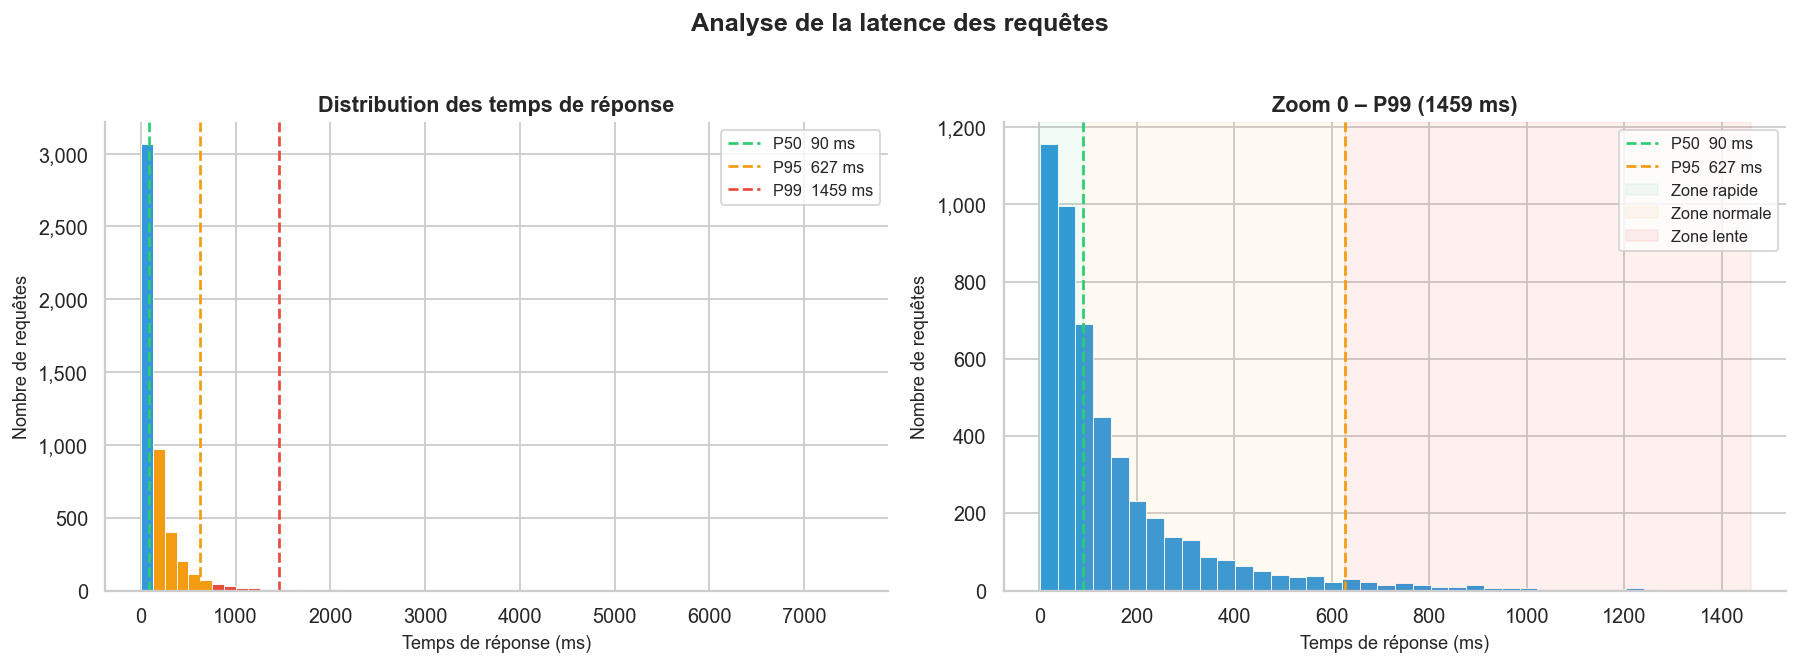

P50  : 90.0 ms
P95  : 627.1 ms
P99  : 1459.0 ms
Max  : 7510.0 ms
Figure sauvegardée : latency_histogram.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Données
rt = df["response_time_ms"].dropna()
p50 = rt.quantile(0.50)
p95 = rt.quantile(0.95)
p99 = rt.quantile(0.99)

# Graphe gauche : histogramme complet 
ax1 = axes[0]
n, bins, patches = ax1.hist(rt, bins=60, color="#3498db", edgecolor="white", linewidth=0.5)

# Colorier les barres au-delà du P95 en rouge
for patch, left in zip(patches, bins[:-1]):
    if left >= p95:
        patch.set_facecolor("#e74c3c")
    elif left >= p50:
        patch.set_facecolor("#f39c12")

# Lignes verticales P50 / P95 / P99
ax1.axvline(p50, color="#2ecc71", linestyle="--", linewidth=1.5, label=f"P50  {p50:.0f} ms")
ax1.axvline(p95, color="#f39c12", linestyle="--", linewidth=1.5, label=f"P95  {p95:.0f} ms")
ax1.axvline(p99, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"P99  {p99:.0f} ms")

ax1.set_title("Distribution des temps de réponse", fontsize=12, fontweight="bold")
ax1.set_xlabel("Temps de réponse (ms)", fontsize=10)
ax1.set_ylabel("Nombre de requêtes", fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.legend(fontsize=9)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Graphe droite : zoom sur 0–P99 (exclut les outliers extrêmes) 
ax2 = axes[1]
rt_zoom = rt[rt <= p99]
ax2.hist(rt_zoom, bins=40, color="#3498db", edgecolor="white", linewidth=0.5)
ax2.axvline(p50, color="#2ecc71", linestyle="--", linewidth=1.5, label=f"P50  {p50:.0f} ms")
ax2.axvline(p95, color="#f39c12", linestyle="--", linewidth=1.5, label=f"P95  {p95:.0f} ms")

# Annotation des zones
ax2.axvspan(0,    p50, alpha=0.06, color="#2ecc71", label="Zone rapide")
ax2.axvspan(p50,  p95, alpha=0.06, color="#f39c12", label="Zone normale")
ax2.axvspan(p95, rt_zoom.max(), alpha=0.08, color="#e74c3c", label="Zone lente")

ax2.set_title(f"Zoom 0 – P99 ({p99:.0f} ms)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Temps de réponse (ms)", fontsize=10)
ax2.set_ylabel("Nombre de requêtes", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.legend(fontsize=9)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Analyse de la latence des requêtes", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("latency_histogram.png", bbox_inches="tight")
plt.show()

print(f"P50  : {p50:.1f} ms")
print(f"P95  : {p95:.1f} ms")
print(f"P99  : {p99:.1f} ms")
print(f"Max  : {rt.max():.1f} ms")
print("Figure sauvegardée : latency_histogram.png")

# **4. FEATURE ENGINEERING**

In [18]:
# Indexer par timestamp pour le resample
df_indexed = df.set_index("timestamp").sort_index()

def compute_window_features(group):
    return pd.Series({
        # Volume
        "request_count" : len(group),
        "unique_ips": group["ip_address"].nunique(),

        # Latence
        "avg_response_time"  : group["response_time_ms"].mean(),
        "median_response_time" : group["response_time_ms"].median(),
        "p95_response_time" : group["response_time_ms"].quantile(0.95),
        "p99_response_time": group["response_time_ms"].quantile(0.99),
        "max_response_time" : group["response_time_ms"].max(),
        "std_response_time": group["response_time_ms"].std() if len(group) > 1 else 0,

        # Taux d'erreurs
        "error_rate_5xx" : group["is_error_5xx"].mean(),
        "error_rate_4xx" : group["is_error_4xx"].mean(),
        "success_rate"  : group["is_success"].mean(),

        # Bytes
        "avg_bytes_sent" : group["bytes_sent"].mean(),
        "total_bytes_sent" : group["bytes_sent"].sum(),

        # Types de clients
        "bot_ratio" : (group["client_type"] == "bot").mean(),
        "mobile_ratio"  : (group["client_type"] == "mobile").mean(),
        "desktop_ratio" : (group["client_type"] == "desktop").mean(),

        # Types d'endpoints
        "api_ratio" : (group["endpoint_type"] == "api").mean(),
        "static_ratio": (group["endpoint_type"] == "static").mean(),
        "auth_ratio" : (group["endpoint_type"] == "auth").mean(),

        # Méthodes HTTP
        "get_ratio"  : (group["method"] == "GET").mean(),
        "post_ratio"  : (group["method"] == "POST").mean(),

        # Contexte temporel
        "hour"   : group["hour"].iloc[0],
        "is_weekend" : group["is_weekend"].iloc[0],
        "is_business_hours" : group["is_business_hours"].iloc[0],
    })

features_df = (
    df_indexed
    .groupby(["server_id", pd.Grouper(freq="5min")])
    .apply(compute_window_features)
    .reset_index()
    .dropna(subset=["avg_response_time"])
)

print(f"Feature engineering terminé")
print(f"Shape : {features_df.shape}")
features_df.head()

Feature engineering terminé
Shape : (4443, 26)


C:\Users\MSI\AppData\Local\Temp\ipykernel_15316\3897448251.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_window_features)


,server_id,timestamp,request_count,unique_ips,avg_response_time,median_response_time,p95_response_time,p99_response_time,max_response_time,std_response_time,...,mobile_ratio,desktop_ratio,api_ratio,static_ratio,auth_ratio,get_ratio,post_ratio,hour,is_weekend,is_business_hours
0,1,2024-01-01 00:15:00,1.0,1.0,153.0,153.0,153.0,153.0,153.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,2024-01-01 00:30:00,1.0,1.0,201.0,201.0,201.0,201.0,201.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,2024-01-01 02:15:00,1.0,1.0,50.0,50.0,50.0,50.0,50.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0
3,1,2024-01-01 05:10:00,1.0,1.0,339.0,339.0,339.0,339.0,339.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0
4,1,2024-01-01 07:00:00,1.0,1.0,145.0,145.0,145.0,145.0,145.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,7.0,0.0,0.0


In [30]:
print("AVANT Feature Engineering ")
print(f"df : {len(df)} lignes - une ligne = une requête HTTP")

print("APRÈS Feature Engineering ")
print(f"features_df : {len(features_df)} lignes - une ligne = une fenêtre de 5 min")

print("COLONNES GÉNÉRÉES")
for col in features_df.columns:
    print(f"  - {col} ({features_df[col].dtype})")

AVANT Feature Engineering 
df : 5000 lignes - une ligne = une requête HTTP
APRÈS Feature Engineering 
features_df : 4443 lignes - une ligne = une fenêtre de 5 min
COLONNES GÉNÉRÉES
  - server_id (int64)
  - timestamp (datetime64[ns])
  - request_count (float64)
  - unique_ips (float64)
  - avg_response_time (float64)
  - median_response_time (float64)
  - p95_response_time (float64)
  - p99_response_time (float64)
  - max_response_time (float64)
  - std_response_time (float64)
  - error_rate_5xx (float64)
  - error_rate_4xx (float64)
  - success_rate (float64)
  - avg_bytes_sent (float64)
  - total_bytes_sent (float64)
  - bot_ratio (float64)
  - mobile_ratio (float64)
  - desktop_ratio (float64)
  - api_ratio (float64)
  - static_ratio (float64)
  - auth_ratio (float64)
  - get_ratio (float64)
  - post_ratio (float64)
  - hour (float64)
  - is_weekend (float64)
  - is_business_hours (float64)
  - is_anomaly (int64)
  - anomaly_type (object)


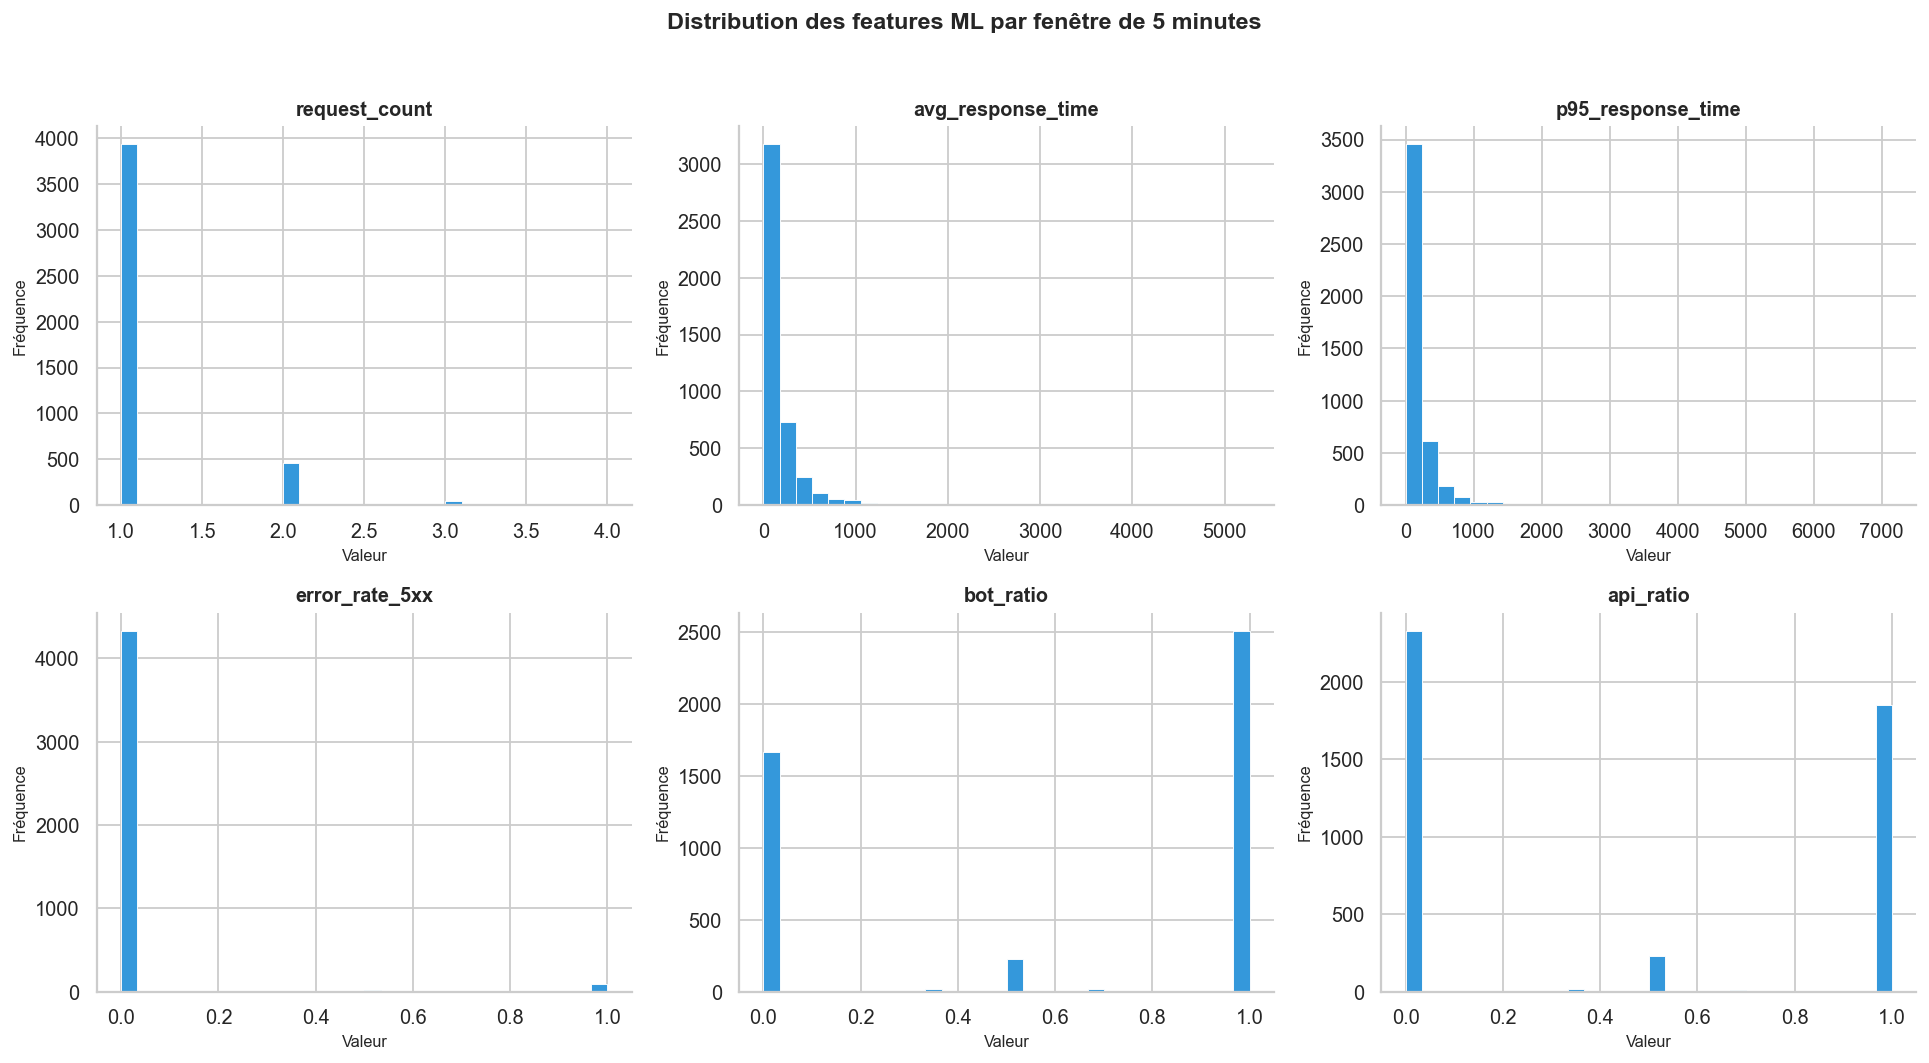

Figure sauvegardée : features_distribution.png


In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

features_to_plot = [
    "request_count",
    "avg_response_time",
    "p95_response_time",
    "error_rate_5xx",
    "bot_ratio",
    "api_ratio",
]

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    ax.hist(features_df[feat].dropna(), bins=30,
            color="#3498db", edgecolor="white", linewidth=0.5)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Valeur", fontsize=9)
    ax.set_ylabel("Fréquence", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Distribution des features ML par fenêtre de 5 minutes",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("features_distribution.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : features_distribution.png")

### Correlation between features

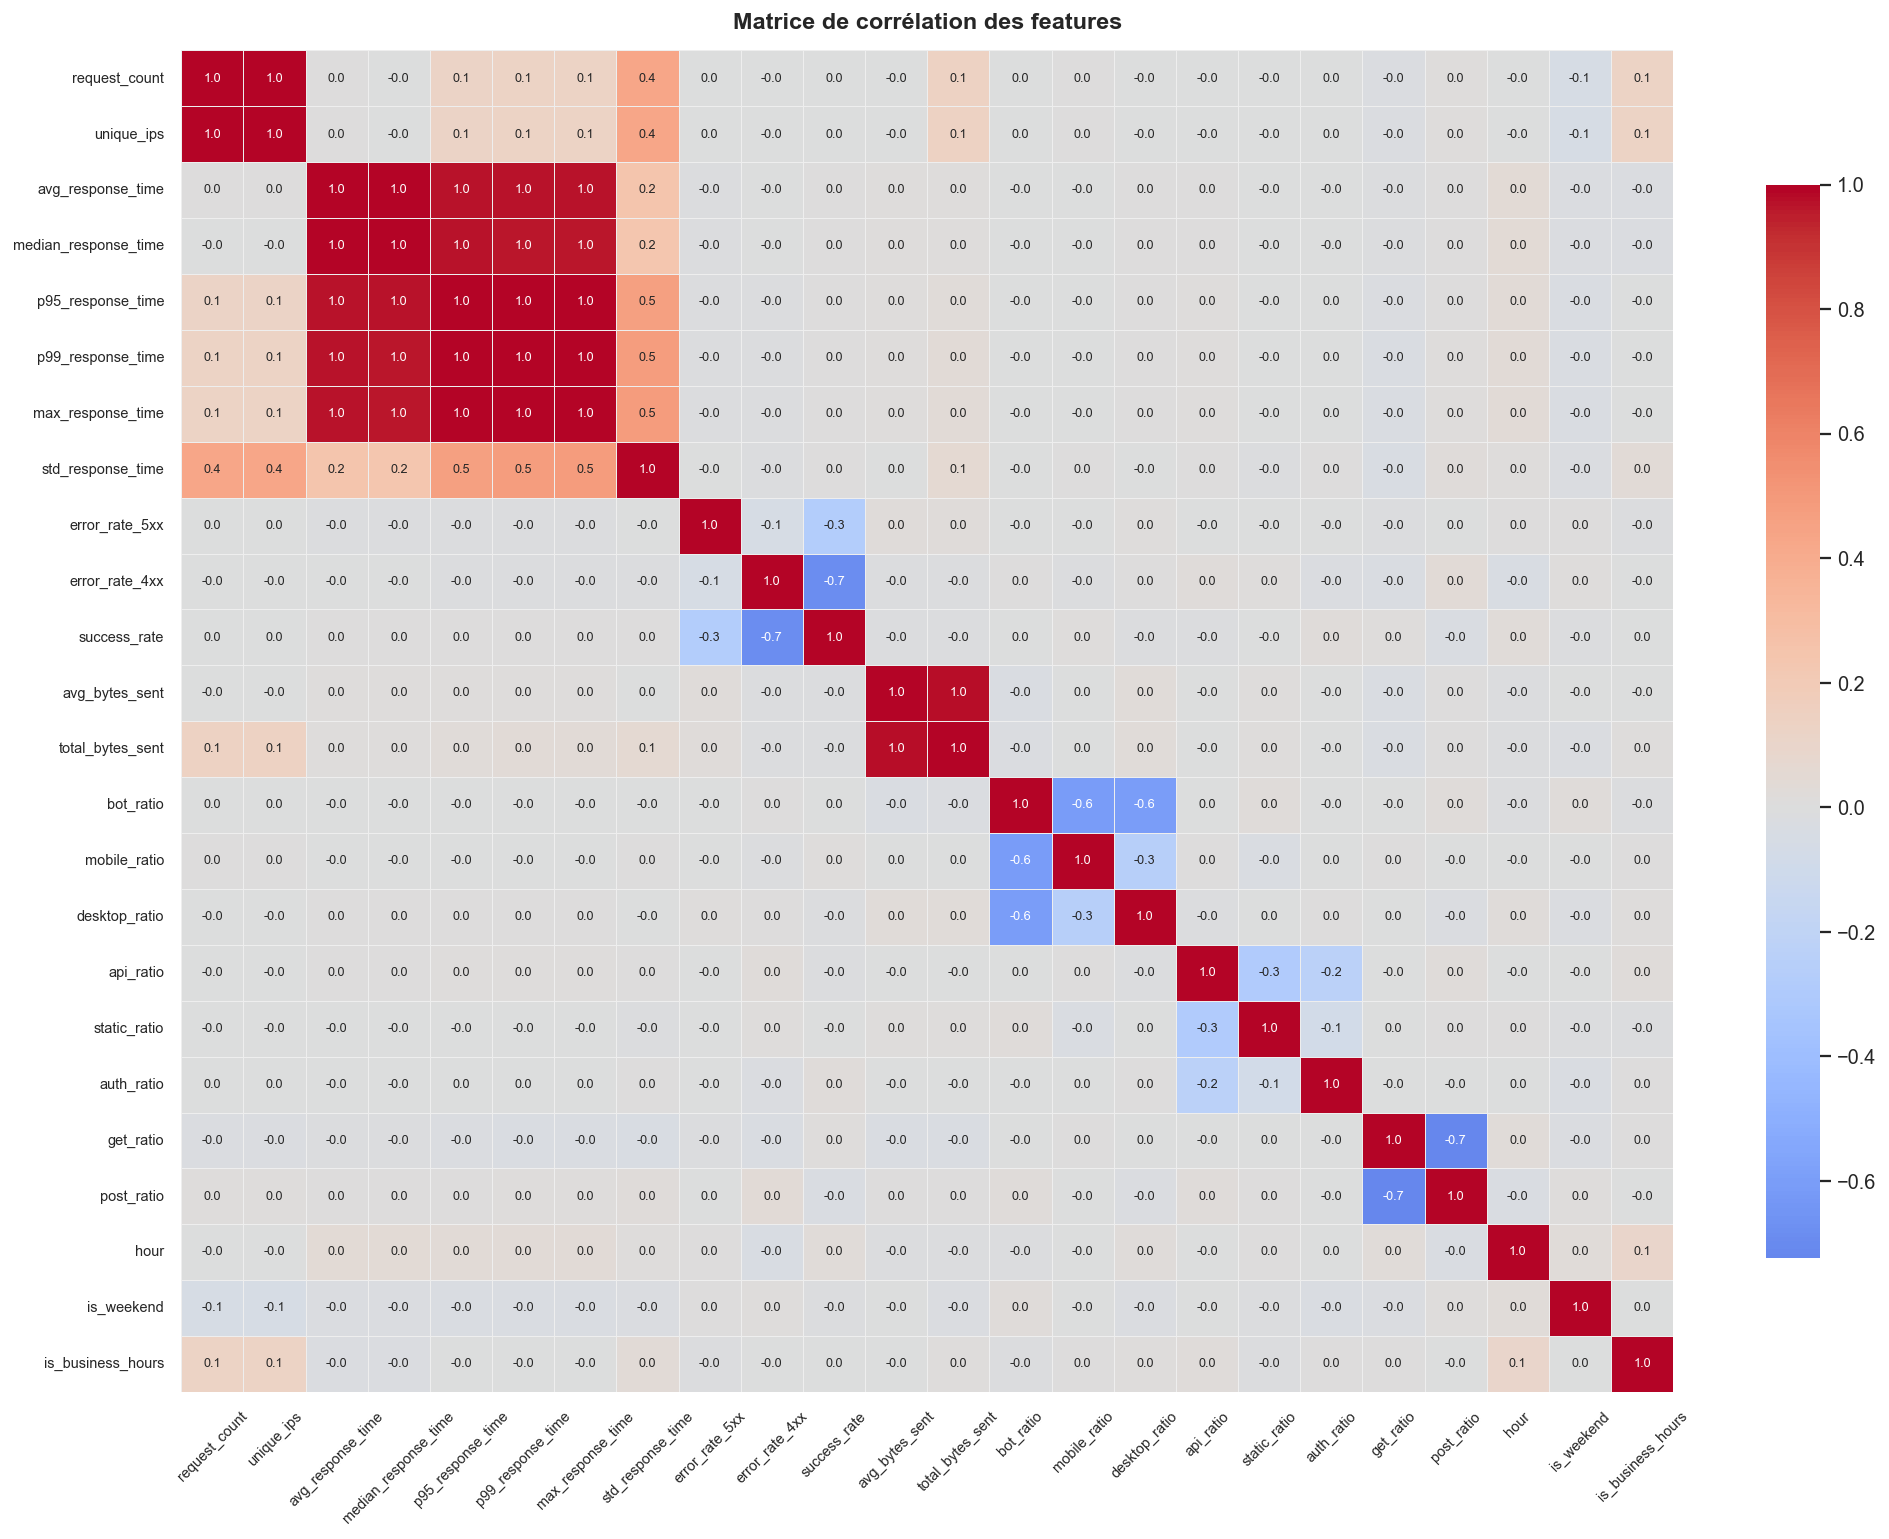

Figure sauvegardée : correlation_matrix.png


In [ ]:
# Colonnes numériques uniquement
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["server_id"]]
corr_matrix = features_df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="#eeeeee",
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Matrice de corrélation des features", fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.tick_params(axis="y", labelsize=8, rotation=0)
plt.tight_layout()
plt.savefig("correlation_matrix.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : correlation_matrix.png")

# **5. Labelling**

In [22]:
SEUIL_ERROR_5XX   = 0.05    # plus de 5% d'erreurs serveur
SEUIL_P95_LATENCE = 2000    # p95 latence > 2 secondes
SEUIL_TRAFIC_MULT = 3.0     # volume x3 par rapport à la moyenne
mean_requests = features_df["request_count"].mean()
print("SEUILS D'ANOMALIE")
print(f"Taux erreur 5xx : > {SEUIL_ERROR_5XX*100}%")
print(f"Latence p95 : > {SEUIL_P95_LATENCE} ms")
print(f"Moyenne req/5min : {mean_requests:.1f}")
print(f"Seuil pic trafic  : > {mean_requests * SEUIL_TRAFIC_MULT:.1f} req/5min")

SEUILS D'ANOMALIE
Taux erreur 5xx : > 5.0%
Latence p95 : > 2000 ms
Moyenne req/5min : 1.1
Seuil pic trafic  : > 3.4 req/5min


In [23]:
#Application des labels
cond_error_5xx = features_df["error_rate_5xx"] > SEUIL_ERROR_5XX
cond_latence = features_df["p95_response_time"] > SEUIL_P95_LATENCE
cond_trafic= features_df["request_count"] > (mean_requests * SEUIL_TRAFIC_MULT)

features_df["is_anomaly"] = (cond_error_5xx | cond_latence | cond_trafic).astype(int)

def anomaly_type(row):
    types = []
    if row["error_rate_5xx"] > SEUIL_ERROR_5XX:
        types.append("error_spike")
    if row["p95_response_time"] > SEUIL_P95_LATENCE:
        types.append("latency_spike")
    if row["request_count"] > mean_requests * SEUIL_TRAFIC_MULT:
        types.append("traffic_spike")
    return ",".join(types) if types else "normal"

features_df["anomaly_type"] = features_df.apply(anomaly_type, axis=1)

print("Labels appliqués")
print(f"\nDistribution :")
print(features_df["is_anomaly"].value_counts())
print(f"\nTypes d'anomalies :")
print(features_df["anomaly_type"].value_counts())

Labels appliqués

Distribution :
is_anomaly
0    4309
1     134
Name: count, dtype: int64

Types d'anomalies :
anomaly_type
normal           4309
error_spike       110
latency_spike      21
traffic_spike       3
Name: count, dtype: int64


Visualisation des anomalies dans le temps

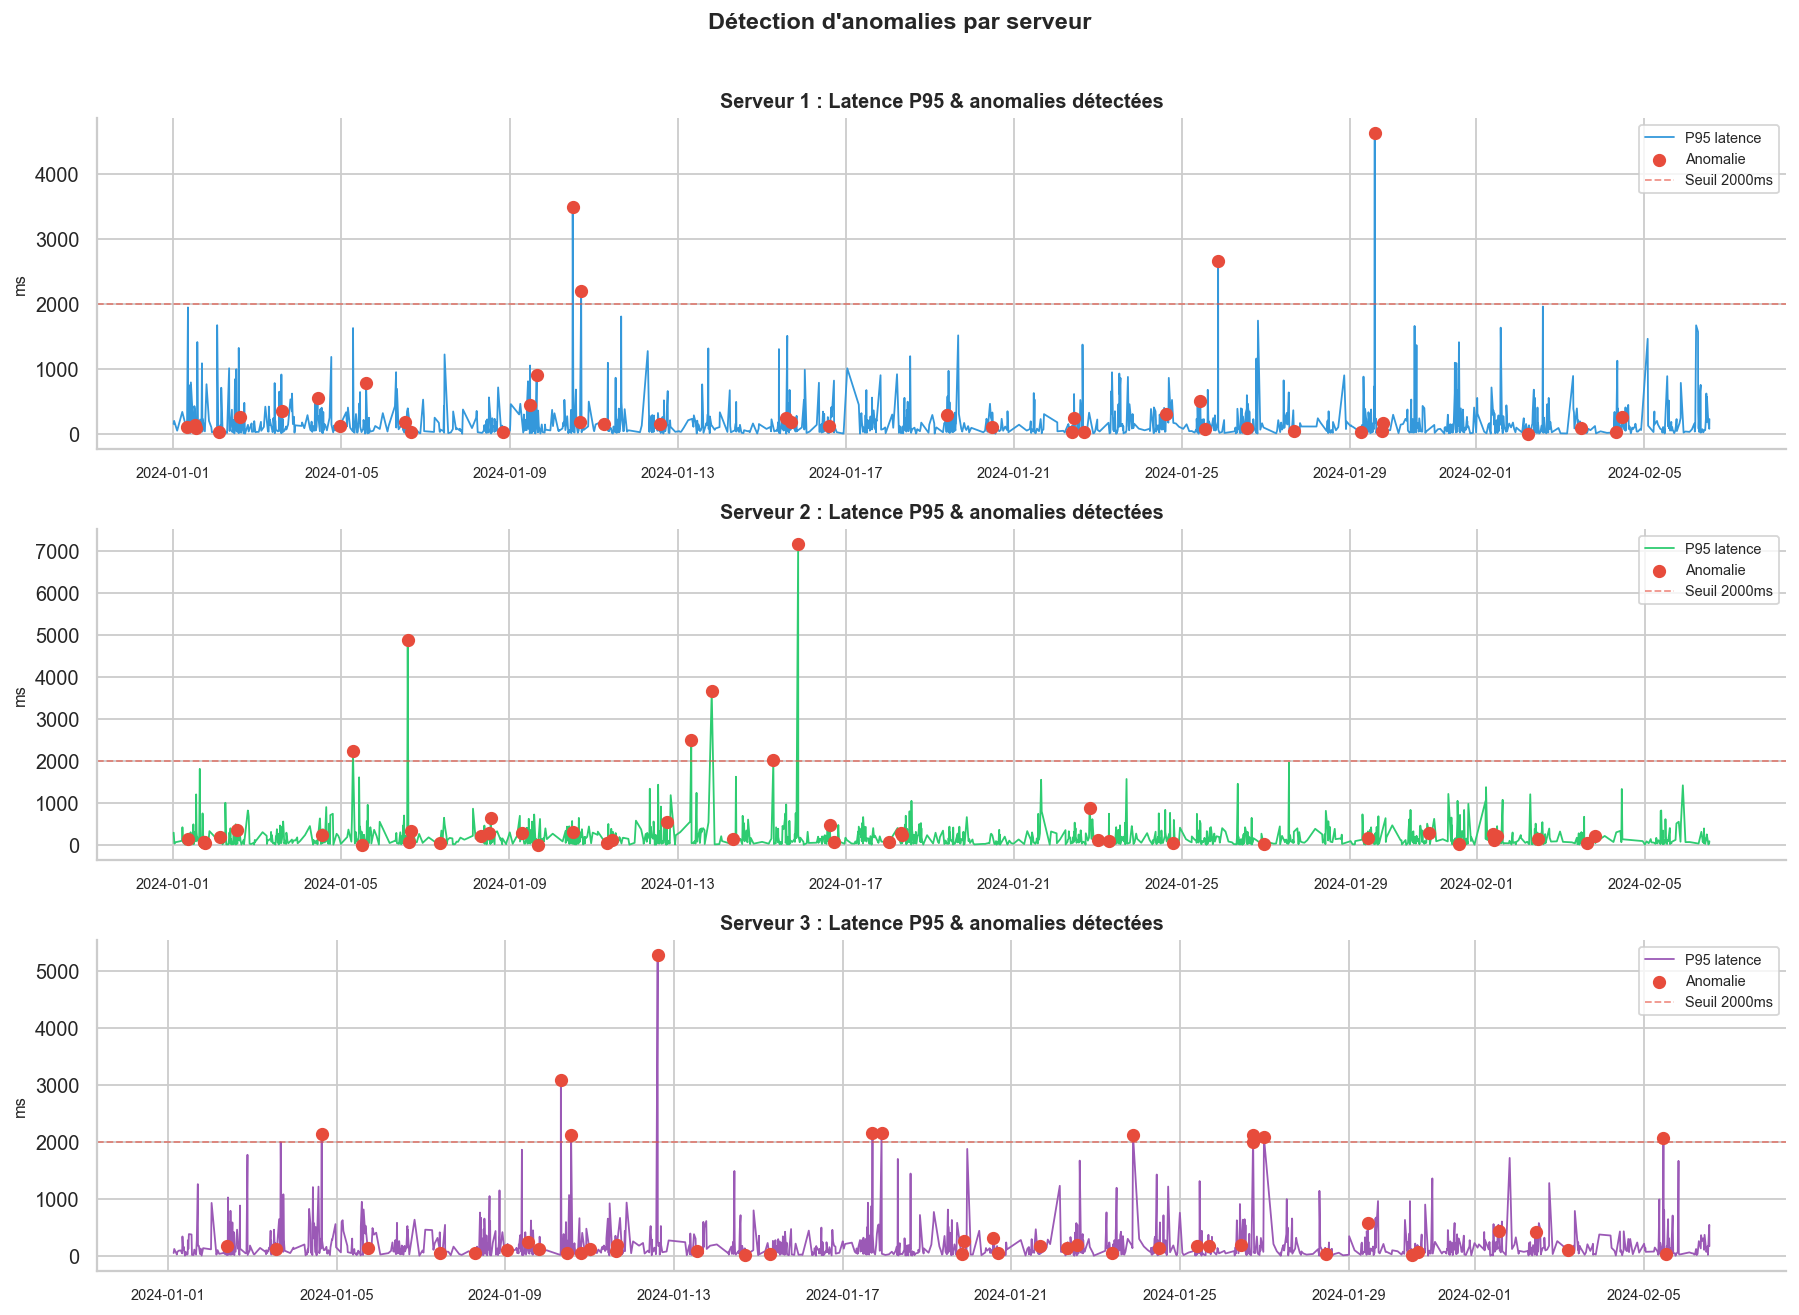

Figure sauvegardée : anomalies_timeline.png


In [25]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

servers = sorted(features_df["server_id"].unique())
colors  = ["#3498db", "#2ecc71", "#9b59b6"]

for i, sid in enumerate(servers):
    sub = features_df[features_df["server_id"] == sid].copy()
    sub = sub.set_index("timestamp").sort_index()

    ax = axes[i]
    ax.plot(sub.index, sub["p95_response_time"],
            color=colors[i], linewidth=1, label="P95 latence")

    anomalies = sub[sub["is_anomaly"] == 1]
    ax.scatter(anomalies.index, anomalies["p95_response_time"],
               color="#e74c3c", s=40, zorder=5, label="Anomalie")

    ax.axhline(SEUIL_P95_LATENCE, color="#e74c3c",
               linestyle="--", linewidth=1, alpha=0.6, label=f"Seuil {SEUIL_P95_LATENCE}ms")

    ax.set_title(f"Serveur {sid} : Latence P95 & anomalies détectées",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("ms", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle("Détection d'anomalies par serveur", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("anomalies_timeline.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : anomalies_timeline.png")

In [ ]:
anomalies = features_df[features_df["is_anomaly"] == 1]

print(f"Total fenêtres analysées : {len(features_df)}")
print(f"Total anomalies : {len(anomalies)}")
print(f"Taux d'anomalies : {len(anomalies)/len(features_df)*100:.1f}%")

print(f"\nAnomalies par serveur :")
print(anomalies.groupby("server_id")["is_anomaly"].count())

print(f"\nMoyennes métriques lors d'anomalies vs normal :")
compare = features_df.groupby("is_anomaly")[
    ["error_rate_5xx", "p95_response_time", "request_count"]
].mean().round(3)
compare.index = ["Normal", "Anomalie"]
print(compare)

Total fenêtres analysées : 4443
Total anomalies          : 134
Taux d'anomalies         : 3.0%

Anomalies par serveur :
server_id
1    41
2    46
3    47
Name: is_anomaly, dtype: int64

Moyennes métriques lors d'anomalies vs normal :
          error_rate_5xx  p95_response_time  request_count
Normal             0.000            178.987          1.119
Anomalie           0.725            619.450          1.328


In [29]:

print(df.shape)
print(df.columns.tolist())

(5000, 25)
['timestamp', 'server_id', 'method', 'path', 'status_code', 'response_time_ms', 'bytes_sent', 'user_agent', 'ip_address', 'referrer', 'is_success', 'is_redirect', 'is_error_4xx', 'is_error_5xx', 'status_category', 'client_type', 'endpoint_type', 'api_name', 'hour', 'minute', 'dayofweek', 'day', 'month', 'is_weekend', 'is_business_hours']


# **6. Normalisation StandardScaler**

In [ ]:
from sklearn.preprocessing import StandardScaler
import pickle

# Exclure les colonnes non-numériques et les métadonnées
EXCLUDE_COLS = ["server_id", "timestamp", "is_anomaly", "anomaly_type"]

# Prendre automatiquement toutes les colonnes numériques restantes
FEATURES_ML = [
    col for col in features_df.columns
    if col not in EXCLUDE_COLS
    and features_df[col].dtype in ["float64", "int64", "float32", "int32"]
]

print(f"Features détectées automatiquement : {len(FEATURES_ML)}")
print(FEATURES_ML)

X = features_df[FEATURES_ML].fillna(0)
y = features_df["is_anomaly"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES_ML)

print(f"Normalisation appliquée")
print(f"Shape X_scaled : {X_scaled.shape}")
print(f"Shape y : {y.shape}")

Features détectées automatiquement : 24
['request_count', 'unique_ips', 'avg_response_time', 'median_response_time', 'p95_response_time', 'p99_response_time', 'max_response_time', 'std_response_time', 'error_rate_5xx', 'error_rate_4xx', 'success_rate', 'avg_bytes_sent', 'total_bytes_sent', 'bot_ratio', 'mobile_ratio', 'desktop_ratio', 'api_ratio', 'static_ratio', 'auth_ratio', 'get_ratio', 'post_ratio', 'hour', 'is_weekend', 'is_business_hours']
Normalisation appliquée
Shape X_scaled : (4443, 24)
Shape y : (4443,)


In [34]:
X_scaled.to_csv("data/X_scaled.csv", index=False)
y.to_csv("data/y_labels.csv", index=False)
features_df.to_csv("data/features_ml.csv", index=False)

with open("data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Fichiers sauvegardés :")
print("  - X_scaled.csv => features normalisées pour le ML")
print("  - y_labels.csv => labels anomalies")
print("  - features_ml.csv => données complètes avec contexte")
print("  - scaler.pkl  => StandardScaler pour l'inférence")

Fichiers sauvegardés :
  - X_scaled.csv => features normalisées pour le ML
  - y_labels.csv => labels anomalies
  - features_ml.csv => données complètes avec contexte
  - scaler.pkl  => StandardScaler pour l'inférence
